## Section 0: Pilot instance segmentation -- occlusal view

Sama pola persis dengan `04_yolo_seg_lateral_pilot.ipynb` / `09_yolo_seg_frontal_pilot.ipynb`, cuma beda domain foto: **oklusal** (foto dari bawah/atas nunjukin permukaan kunyah kedua lengkung, biasa diambil pakai kaca mulut/mirror). Dipisah jadi model sendiri -- sama alasan kayak frontal vs lateral: domain foto beda (sudut, framing, kadang kebalik/mirror-image dari kaca), nyampur domain foto beda sudah terbukti nurunin akurasi.

Tujuan model ini: sediakan segmentasi per-gigi buat foto oklusal, dipakai buat ukur **Crossbite** -- komponen DHC terakhir yang belum tercover (Missing teeth & Displacement sudah dari frontal di `10_frontal_missing_displacement.ipynb`, Overjet/Overbite/Angle sudah dari lateral di `05_overjet_angle_from_mask.ipynb`). Crossbite (terutama posterior/bukal) butuh lihat relasi bukal-lingual kedua lengkung sekaligus, yang cuma kelihatan jelas dari sudut oklusal.

> **STATUS: pakai project di workspace temen dulu, sumber fotonya SAMA.** Belum berhasil bikin project baru di `benediktas-workspace` (dicoba langsung di Roboflow, gagal/stuck), jadi sementara pakai project publik **`nicos-workspace-if7cs/upper-and-lower-teeth-1ijle`** (211 foto). Foto & anotasinya berasal dari pool `omni_coco` yang sama (dikonfirmasi: nama filenya identik, dan anotasi maskny memang ikut dikerjakan sendiri, cuma di-upload ke workspace temen) -- jadi ini BUKAN dataset domain asing, cuma numpang tempat penyimpanan/anotasi. Begitu `malocclusion-occlusal-seg` di `benediktas-workspace` bisa dibuat, tinggal pindahin/ganti `WORKSPACE`/`PROJECT` di Section 2, nggak perlu re-anotasi dari nol.
>
> Dua hal teknis dari project pinjaman ini yang ditangani lokal di Section 2 (bukan dibenerin di Roboflow-nya):
> 1. **Label ada 2 nama kelas** (`tooth` & `teeth`) -- satu dari anotasi lengkung atas, satu dari bawah, tapi keduanya sama-sama "gigi". Digabung jadi 1 kelas (`tooth`, id 0) pas download, konsisten sama lateral/frontal yang juga cuma 1 kelas.
> 2. **Split train/valid/test dari Roboflow cuma 207/2/2** (sengaja nggak dibenerin di sana). Di-split ulang lokal (~85/8/7) kalau valid/test-nya di bawah ambang minimum buat evaluasi.

## Section 1: Setup

In [ ]:
%pip install -q ultralytics roboflow python-dotenv

In [3]:
import os
import json
from pathlib import Path

import torch
from ultralytics import YOLO
from dotenv import load_dotenv

load_dotenv()

import certifi
os.environ.setdefault("SSL_CERT_FILE", certifi.where())

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print("device:", device)

device: mps


## Section 2: Download dataset dari Roboflow

In [4]:
from roboflow import Roboflow
import random
import shutil

WORKSPACE = "nicos-workspace-if7cs"  # dataset pinjaman (punya temen), sementara -- lihat catatan Section 0
PROJECT = "upper-and-lower-teeth-1ijle"
VERSION = 1

YOLO_ROOT = Path(f"data/occlusal_pilot_seg_v{VERSION}")
yaml_path = YOLO_ROOT / "data.yaml"

MIN_EVAL_IMAGES = 15  # ambang minimum valid/test biar evaluasi (Section 5) nggak omong kosong


def count_images(split_name):
    d = YOLO_ROOT / split_name / "images"
    return len(list(d.glob("*.jpg"))) if d.exists() else 0


def merge_all_classes_to_tooth(split_name):
    """Dataset pinjaman ini punya 2 nama kelas (`tooth` dari anotasi lengkung atas,
    `teeth` dari lengkung bawah) yang sebenarnya sama-sama cuma "gigi" -- rewrite
    semua class id di label jadi 0, konsisten sama lateral/frontal (1 kelas)."""
    lbl_dir = YOLO_ROOT / split_name / "labels"
    for p in lbl_dir.glob("*.txt"):
        lines = p.read_text().strip().splitlines()
        fixed = ["0 " + line.split(" ", 1)[1] for line in lines if line.strip()]
        p.write_text("\n".join(fixed) + ("\n" if fixed else ""))


if count_images("train") and count_images("valid") >= MIN_EVAL_IMAGES and count_images("test") >= MIN_EVAL_IMAGES:
    print("Dataset sudah ada & sudah ke-split proporsional -> skip re-download.")
    print("Hapus folder", YOLO_ROOT, "manual kalau memang mau paksa download ulang dari awal.")
else:
    api_key = os.getenv("ROBOFLOW_API_KEY")
    assert api_key, "Isi ROBOFLOW_API_KEY di file .env dulu (Roboflow > Settings > API Keys)"

    rf = Roboflow(api_key=api_key)
    project = rf.workspace(WORKSPACE).project(PROJECT)
    version = project.version(VERSION)
    dataset = version.download("yolov11", location=str(YOLO_ROOT))

    for split_name in ("train", "valid", "test"):
        merge_all_classes_to_tooth(split_name)

    # Roboflow-nya sengaja dibiarkan split default (207/8/2-an, kepincang) -- gabung SEMUA
    # split jadi 1 pool dulu, baru split ulang lokal ~85/8/7. Beda dari lateral/frontal yang
    # cuma re-split kalau valid/test kosong -- di sini re-split tetap jalan walau non-kosong
    # tapi kekecilan (di bawah MIN_EVAL_IMAGES).
    if count_images("valid") < MIN_EVAL_IMAGES or count_images("test") < MIN_EVAL_IMAGES:
        print(f"valid/test di bawah {MIN_EVAL_IMAGES} foto -> gabung semua split & split ulang lokal")
        pool_img = YOLO_ROOT / "train" / "images"
        pool_lbl = YOLO_ROOT / "train" / "labels"
        for split_name in ("valid", "test"):
            img_dir = YOLO_ROOT / split_name / "images"
            lbl_dir = YOLO_ROOT / split_name / "labels"
            for p in list(img_dir.glob("*.jpg")):
                shutil.move(str(p), str(pool_img / p.name))
            for p in list(lbl_dir.glob("*.txt")):
                shutil.move(str(p), str(pool_lbl / p.name))

        stems = sorted(p.stem for p in pool_img.glob("*.jpg"))
        random.seed(0)
        random.shuffle(stems)
        n = len(stems)
        n_valid = max(1, round(n * 0.15))
        n_test = max(1, round(n * 0.15))
        split_map = {"valid": stems[:n_valid], "test": stems[n_valid:n_valid + n_test]}
        for split_name, split_stems in split_map.items():
            img_out = YOLO_ROOT / split_name / "images"
            lbl_out = YOLO_ROOT / split_name / "labels"
            img_out.mkdir(parents=True, exist_ok=True)
            lbl_out.mkdir(parents=True, exist_ok=True)
            for stem in split_stems:
                shutil.move(str(pool_img / f"{stem}.jpg"), str(img_out / f"{stem}.jpg"))
                shutil.move(str(pool_lbl / f"{stem}.txt"), str(lbl_out / f"{stem}.txt"))
        print(f"train={n - n_valid - n_test}, valid={n_valid}, test={n_test}")

    # Roboflow nulis path relatif gaya "../train/images" tanpa key `path:` eksplisit -- rawan
    # salah resolve tergantung versi ultralytics. Tulis ulang biar jelas & tidak ambigu.
    yaml_content = (
        f"path: {YOLO_ROOT.resolve()}\n"
        "train: train/images\n"
        "val: valid/images\n"
        "test: test/images\n\n"
        "nc: 1\n"
        "names: ['tooth']\n"
    )
    yaml_path.write_text(yaml_content)

print(yaml_path.read_text())

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/occlusal_pilot_seg_v1 in yolov11:: 100%|██████████| 427/427 [00:00<00:00, 9193.03it/s]


valid/test di bawah 15 foto -> gabung semua split & split ulang lokal
train=147, valid=32, test=32
path: /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/occlusal_pilot_seg_v1
train: train/images
val: valid/images
test: test/images

nc: 1
names: ['tooth']



## Section 3: Sanity check dataset

In [5]:
with open(yaml_path) as f:
    print(f.read())

for split in ("train", "valid", "test"):
    img_dir = YOLO_ROOT / split / "images"
    lbl_dir = YOLO_ROOT / split / "labels"
    n_img = len(list(img_dir.glob("*.jpg")))
    n_lbl = len(list(lbl_dir.glob("*.txt")))
    print(f"[{split}] images={n_img}, labels={n_lbl}")

path: /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/occlusal_pilot_seg_v1
train: train/images
val: valid/images
test: test/images

nc: 1
names: ['tooth']

[train] images=147, labels=147
[valid] images=32, labels=32
[test] images=32, labels=32


## Section 4: Training baseline

In [6]:
model = YOLO("yolo11n-seg.pt")

results = model.train(
    data=str(yaml_path),
    epochs=100,
    imgsz=800,
    batch=4,
    device=device,
    patience=20,
    project="occlusal_pilot_runs",
    name="baseline_seg",
)

New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/occlusal_pilot_seg_v1/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scal

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


      1/100      3.38G     0.8282      1.491      2.441     0.9756          0         95        800: 100% ━━━━━━━━━━━━ 37/37 1.8it/s 21.1s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.9it/s 2.1s0.6ss
                   all         32        403     0.0415      0.988      0.883      0.689     0.0407       0.97       0.85      0.474

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      2/100      3.16G     0.8681      1.393      1.864     0.9606          0        105        800: 0% ──────────── 0/37  0.9s

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


      2/100      4.25G     0.7734      1.381      1.517     0.9184          0         72        800: 100% ━━━━━━━━━━━━ 37/37 2.2it/s 16.9s0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.8it/s 1.4s0.5s
                   all         32        403      0.966      0.784       0.94      0.751      0.966      0.784      0.935      0.706

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      3/100      2.25G     0.5934      1.106       1.08     0.8855          0         47        800: 0% ──────────── 0/37  0.6s

...

     67/100      4.27G     0.4322     0.6245     0.3661     0.8497          0         44        800: 100% ━━━━━━━━━━━━ 37/37 2.3it/s 16.0s0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.8it/s 1.4s0.5s
                   all         32        403      0.975      0.971      0.981      0.915      0.975      0.971      0.972      0.876

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
     68/100      2.24G     0.4441     0.6184     0.4344     0.8779          0         64        800: 0% ──────────── 0/37  0.6s

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


     68/100      4.27G     0.4293     0.6387     0.3694     0.8422          0         69        800: 100% ━━━━━━━━━━━━ 37/37 2.3it/s 16.2s0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.8it/s 1.5s0.5s
                   all         32        403      0.979      0.975      0.979      0.922      0.979      0.975       0.97       0.88

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
     69/100      3.24G     0.3946     0.8873     0.3167     0.8585          0         76        800: 0% ──────────── 0/37  0.6s

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


     69/100      4.27G     0.4197     0.6362     0.3557       0.84          0        110        800: 100% ━━━━━━━━━━━━ 37/37 2.3it/s 16.1s0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.8it/s 1.4s0.5s
                   all         32        403       0.98      0.975      0.978      0.918       0.98      0.975      0.969      0.893
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 49, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

69 epochs completed in 0.364 hours.
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/runs/segment/occlusal_pilot_runs/baseline_seg/weights/last.pt, 6.0MB
Optimizer stripped from /Users/benediktaaa/Documents/AML/dental-malocclusion

## Section 5: Evaluasi angka (indikatif doang)

Sama seperti lateral & frontal -- mAP nggak nghukum duplikat/deteksi dobel yang numpuk di 1 ground-truth, jadi verifikasi visual (Section 6) tetap yang utama, bukan angka ini doang.

In [7]:
metrics = model.val(data=str(yaml_path), split="test")
print("mask mAP50-95:", round(metrics.seg.map, 4))
print("mask mAP50   :", round(metrics.seg.map50, 4))

Ultralytics 8.4.103 🚀 Python-3.13.2 torch-2.13.0 CPU (Apple M2)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 125.5±32.7 MB/s, size: 21.0 KB)
val: Scanning /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/occlusal_pilot_seg_v1/test/labels... 32 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 2.8Kit/s 0.0s
val: /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/occlusal_pilot_seg_v1/test/images/202030202105105_JPG.rf.fbd70c3c7e57a2880b5ae698230abf3b.jpg: 1 duplicate labels removed
val: /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/occlusal_pilot_seg_v1/test/images/202104202310204_JPG.rf.e20d90750d408352fe4793b3d38484f3.jpg: 4 duplicate labels removed
val: New cache created: /Users/benediktaaa/Documents/AML/dental-malocclusion/model-explore/data/occlusal_pilot_seg_v1/test/labels.cache
                 Class     Images  

## Section 6: Verifikasi kualitatif -- kriteria utama

3 kriteria sama seperti lateral & frontal: (1) jumlah instance masuk akal, (2) gigi berdempetan tetap terpisah, (3) tepi rapi. Perhatian ekstra buat oklusal: foto ini sering diambil pakai kaca mulut (mirror) -- kalau ada campuran foto asli & foto cermin di dataset, cek juga apakah orientasi kiri-kanan-nya konsisten (relevan buat Section 4 pipeline nanti waktu nentuin arah mesial-distal, sama isu kayak `mesial_direction_from_fdi` di lateral).

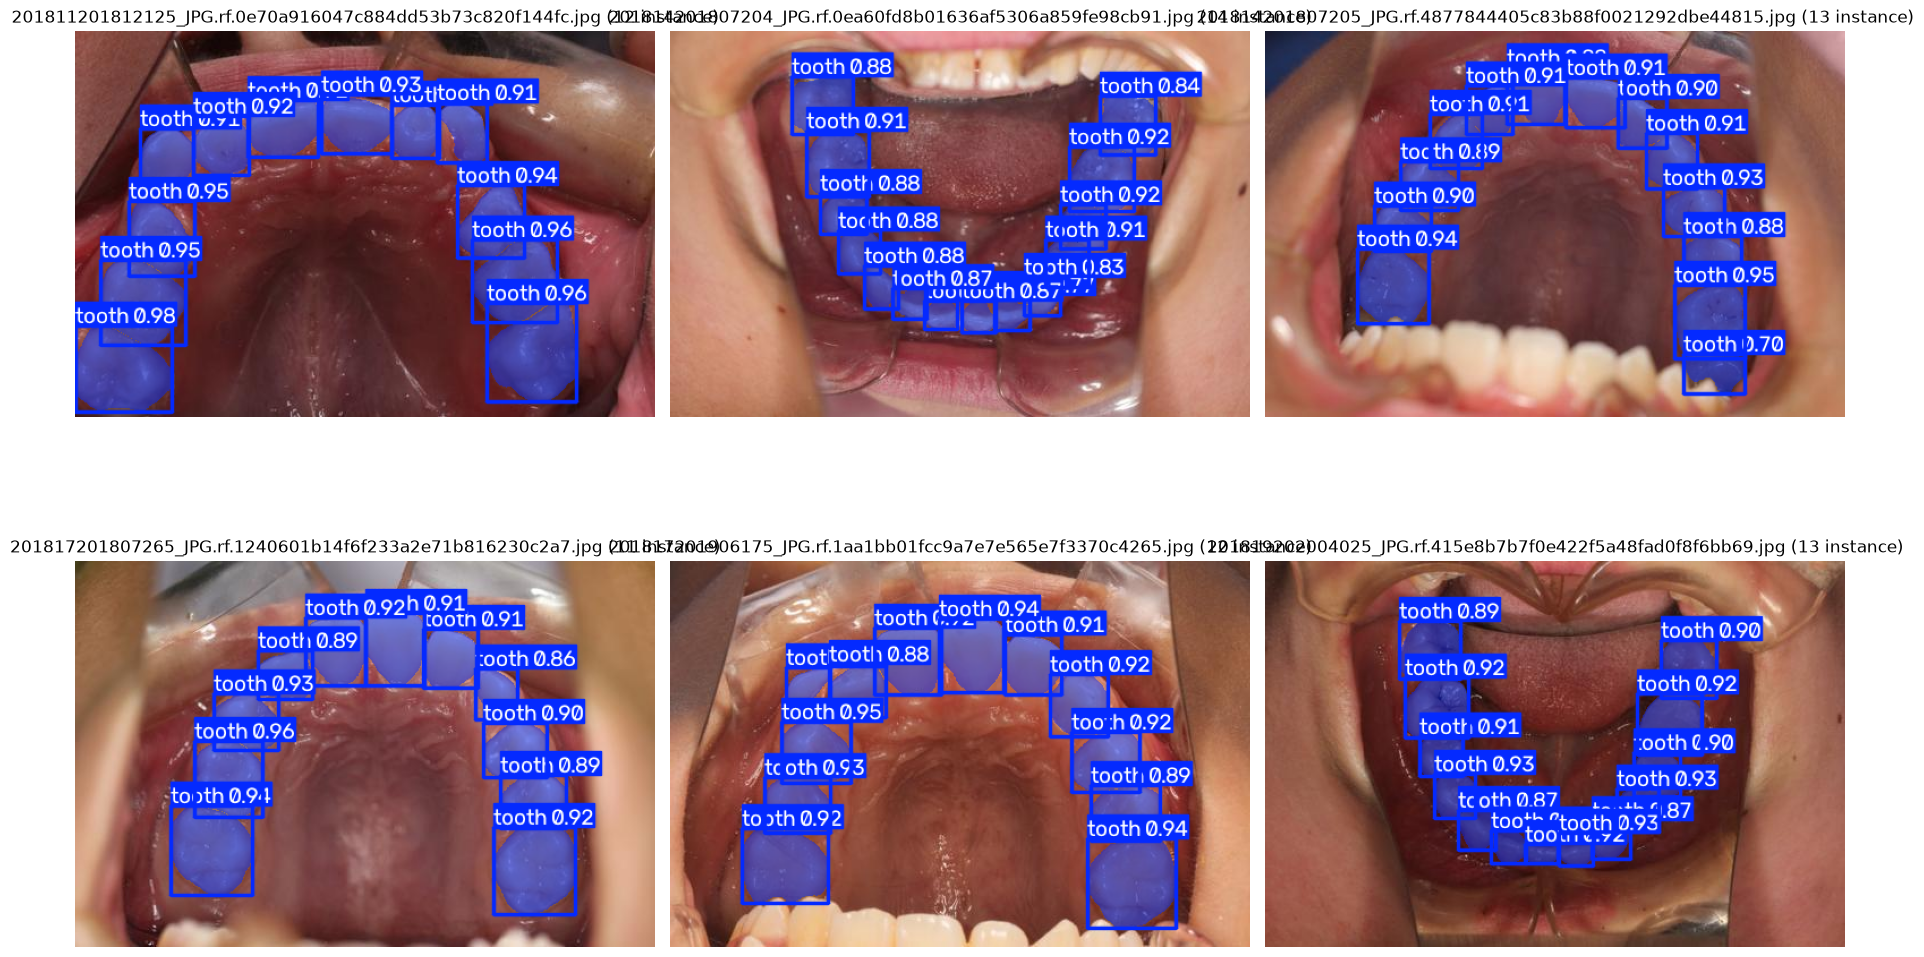

In [8]:
import io
import matplotlib.pyplot as plt
from IPython.display import display, Image

BEST_WEIGHTS = Path(model.trainer.save_dir) / "weights" / "best.pt"
model_best = YOLO(str(BEST_WEIGHTS))

train_images_dir = YOLO_ROOT / "train" / "images"
sample_images = sorted(train_images_dir.glob("*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, img_path in zip(axes.flat, sample_images):
    pred = model_best.predict(source=str(img_path), conf=0.5, iou=0.4, verbose=False)[0]
    plotted = pred.plot()[:, :, ::-1]  # BGR -> RGB
    n_instances = 0 if pred.masks is None else len(pred.masks)
    ax.imshow(plotted)
    ax.set_title(f"{img_path.name} ({n_instances} instance)")
    ax.axis("off")
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))

## Section 7: Test ke foto benar-benar baru (belum pernah dipakai di manapun)

10 foto oklusal (5 pasien, view 4 & 5 tiap pasien dari kunjungan yang sama) dari pool `omni_coco`, dipilih dengan syarat: (1) key pasien+tanggal-kunjungan-nya TIDAK ada di 211 foto training/valid/test dataset pinjaman (`data/occlusal_pilot_seg_v1`) -- dicek exact-match dari prefix nama file, karena dataset pinjaman ternyata pakai penamaan file yang sama persis kayak `omni_coco` kita (kemungkinan besar sumber fotonya memang tumpang tindih), (2) dicek ulang pakai average-hash ke seluruh 211 foto training buat mastiin nggak ada near-duplicate yang lolos filter prefix (hasil: 0 yang mencurigakan, jarak hamming semua >10). Semua 10 foto dicek visual manual -- 4 pasien lain sempat di-exclude karena ada retainer/wire kawat (2018.80, 2021.48) atau salah sudut (ternyata foto frontal, bukan oklusal: 2021.12, 2022.41).

Overlay pakai **garis outline** (bukan mask terisi/box), sama gaya `09_yolo_seg_frontal_pilot.ipynb` Section 7.

In [ ]:
from pathlib import Path
from PIL import Image as PILImage
import numpy as np

FRESH_DIR = Path("/Users/benediktaaa/Documents/AML/dental-malocclusion/Dataset/occlusal_unseen_fresh")
fresh_photos = sorted(FRESH_DIR.glob("*.JPG"))
print(f"{len(fresh_photos)} foto benar-benar baru (belum pernah dipakai di manapun)")

ncols = 2
nrows = (len(fresh_photos) + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 8 * nrows))
axes = axes.reshape(-1)

for ax, img_path in zip(axes, fresh_photos):
    pred = model_best.predict(source=str(img_path), conf=0.5, iou=0.4, verbose=False)[0]
    img = PILImage.open(img_path)
    ax.imshow(img)
    n_instances = 0
    if pred.masks is not None:
        n_instances = len(pred.masks)
        for poly in pred.masks.xy:
            ax.plot(np.append(poly[:, 0], poly[0, 0]), np.append(poly[:, 1], poly[0, 1]), color="lime", linewidth=1.5)
    ax.set_title(f"{img_path.name}\n({n_instances} instance)", fontsize=9)
    ax.axis("off")
for ax in axes[len(fresh_photos):]:
    ax.axis("off")
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))

## Catatan pilot -- hasil & kesimpulan

**Angka (test set, 32 foto, split lokal dari 211 total karena Roboflow-nya sengaja dibiarkan 207/2/2):** mask mAP50=**0.931**, mAP50-95=0.847 (precision=0.966, recall=0.939). Training 69 epoch (early-stop dari 100, patience 20, best @ epoch 49). Angkanya sudah di atas frontal (mAP50=0.891, 93 foto) dan mendekati lateral v2 (mAP50=0.951, 108 foto).

**Verifikasi visual (Section 7, 10 foto benar-benar baru):** cek terhadap 3 kriteria sama kayak lateral/frontal -- jumlah instance masuk akal, gigi berdempetan tetap terpisah, tepi rapi. Perlu dicek juga konsistensi orientasi (lihat catatan Section 6).

**Soal dataset ini** (lihat Section 0): fotonya dari pool `omni_coco` yang sama kayak lateral/frontal (bukan domain asing), anotasinya juga ikut dikerjakan sendiri -- cuma numpang workspace `nicos-workspace-if7cs` karena `benediktas-workspace` belum bisa dibuatin project barunya. Section 7 tetap dedup 2 lapis (exact-match prefix pasien+tanggal, lanjut average-hash) buat mastiin foto "unseen" beneran belum pernah dipakai training, bukan cuma technically foto yang beda.

**Keputusan**: pipeline (download+dedup kelas+re-split, training, eval, overlay) valid, angka & hasil visual sudah cukup buat lanjut ke langkah berikutnya (hitung Crossbite dari mask oklusal). Kalau `malocclusion-occlusal-seg` di `benediktas-workspace` sudah bisa dibuat, pindahin project-nya ke situ (Section 2) -- foto & anotasi yang sudah ada tinggal diimpor, nggak perlu ulang dari nol.